In [3]:
%matplotlib qt
import mne
import os
import numpy as np
import scipy

c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\externals\tempita\__init__.py:35: DeprecationWarning: 'cgi' is deprecated and slated for removal in Python 3.13
  import cgi


In [7]:
subject = '011'
raw = mne.io.read_raw_eeglab(r'E:\elife_active_inference\preprocessed_data\ZS_SUB_'+subject+'.set',preload = True)
picks = mne.pick_types(raw.info, eeg=True,eog = True)
ica = mne.preprocessing.ICA(n_components=105, random_state=97, max_iter='auto')
ica.fit(raw, picks=picks, decim=3,)
# mne.viz.plot_ica_components(ica)

Reading E:\elife_active_inference\preprocessed_data\ZS_SUB_011.fdt
Reading 0 ... 467250  =      0.000 ...  1869.000 secs...
Fitting ICA to data using 105 channels (please be patient, this may take a while)


C:\Users\dell\AppData\Local\Temp\ipykernel_27124\119344368.py:2: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(r'E:\elife_active_inference\preprocessed_data\ZS_SUB_'+subject+'.set',preload = True)
C:\Users\dell\AppData\Local\Temp\ipykernel_27124\119344368.py:2: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(r'E:\elife_active_inference\preprocessed_data\ZS_SUB_'+subject+'.set',preload = True)
c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\utils\check.py:92: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  LooseVersion(library.__version__) < LooseVersion(min_version):
c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\utils\check.py:92: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  Loos

Selecting by number: 105 components


C:\Users\dell\AppData\Local\Temp\ipykernel_27124\119344368.py:5: RuntimeWarning: Using n_components=105 (resulting in n_components_=105) may lead to an unstable mixing matrix estimation because the ratio between the largest (94) and smallest (9.4e-16) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 41
  ica.fit(raw, picks=picks, decim=3,)


Fitting ICA took 103.9s.


Method,fastica
Fit,92 iterations on raw data (155751 samples)
ICA components,105
Explained variance,100.0 %
Available PCA components,105
Channel types,eeg
ICA components marked for exclusion,—


In [8]:
mne.viz.plot_ica_components(ica)

c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\utils\check.py:92: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  LooseVersion(library.__version__) < LooseVersion(min_version):
c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\utils\check.py:92: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  LooseVersion(library.__version__) < LooseVersion(min_version):
c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\utils\check.py:92: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  LooseVersion(library.__version__) < LooseVersion(min_version):
c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\utils\check.py:92: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  LooseVersion(library.__version__) < LooseVersion(min_version):
c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\utils\check.

[<MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 975x260 with 5 Axes>]

In [9]:
exclude_ica = [92,95]
ica.exclude.extend(exclude_ica)
raw_corrected = raw.copy()  # 复制原始数据以保留原始数据不变
ica.apply(raw_corrected)
mne.export.export_raw('E:/elife_active_inference/preprocessed_data/ZS_SUB_'+subject+'_cleaned.set', raw_corrected, fmt='eeglab')

Applying ICA to Raw instance
    Transforming to ICA space (105 components)
    Zeroing out 2 ICA components
    Projecting back using 105 PCA components


In [21]:
raw_corrected = raw.copy()  # 复制原始数据以保留原始数据不变
ica.apply(raw_corrected)
mne.export.export_raw('E:/elife_active_inference/preprocessed_data/ZS_SUB_'+subject+'_cleaned.set', raw_corrected, fmt='eeglab')

Applying ICA to Raw instance
    Transforming to ICA space (105 components)
    Zeroing out 6 ICA components
    Projecting back using 105 PCA components


<RawEEGLAB | ZS_SUB_001.fdt, 105 x 474501 (1898.0 s), ~380.2 MB, data loaded>

Creating RawArray with float64 data, n_channels=105, n_times=473751
    Range : 0 ... 473750 =      0.000 ...  1895.000 secs
Ready.


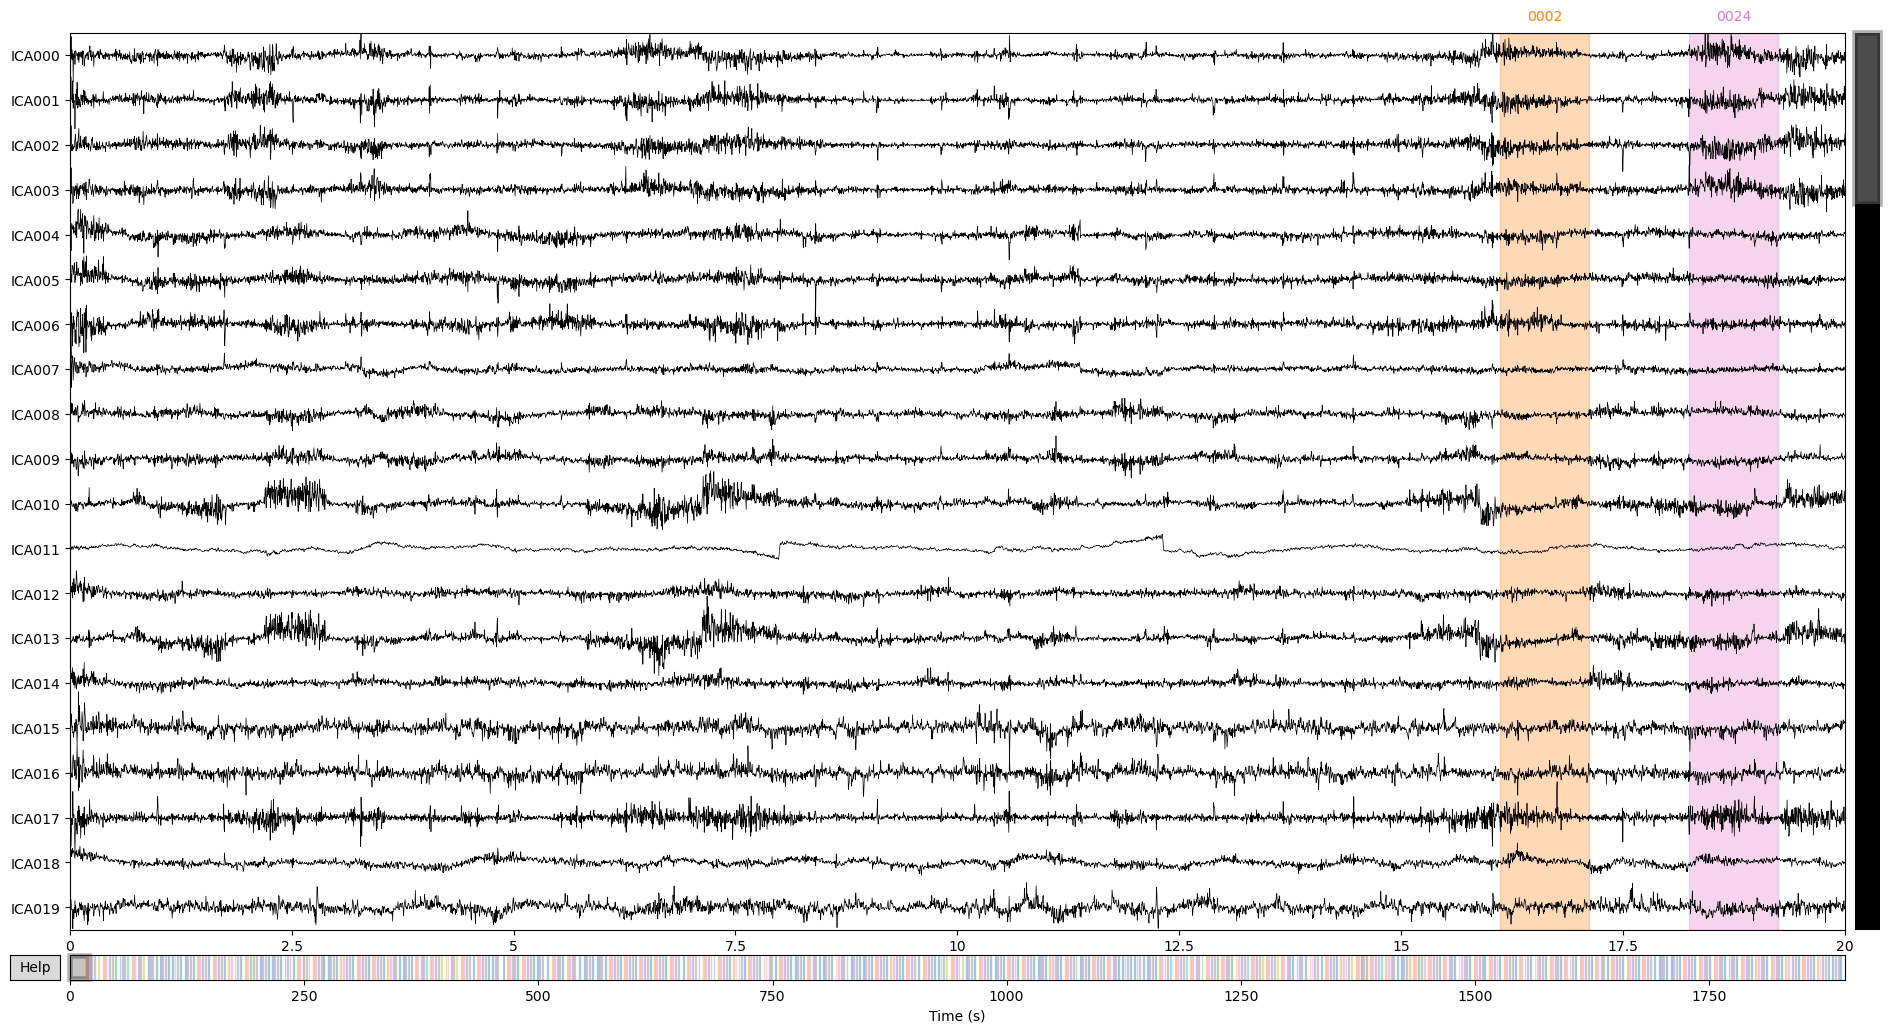

In [44]:
ica.plot_sources(raw)

In [10]:
ica_data = ica.get_sources(raw).get_data()
kurtosis_values = scipy.stats.kurtosis(ica_data, axis=1)
high_kurtosis_components = np.where(kurtosis_values > np.percentile(kurtosis_values, 90))[0]  # 假设噪声分量具有较高的峰度

# 将这些高峰度分量标记为噪声
# ica.exclude.extend(high_kurtosis_components)
print(high_kurtosis_components)

[ 1  2  4  6  7  9 19 27 70 78 84]
